In [13]:
import os

# Your Kaggle username is the name after 'kaggle.com/' in your profile URL
os.environ['KAGGLE_USERNAME'] = 'ishani_singh' # <--- Change this to your actual Kaggle username
os.environ['KAGGLE_KEY'] = 'KGAT_1dbb3477dfcf8444790b01481046cd5b'

print("Credentials set successfully.")

Credentials set successfully.


In [14]:
# 1. Force install and ensure it's in the current environment
import sys
!{sys.executable} -m pip install kaggle

# 2. Re-set your credentials (just in case)
import os
os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME' # Replace with your actual username
os.environ['KAGGLE_KEY'] = 'KGAT_1dbb3477dfcf8444790b01481046cd5b'

# 3. Use the Python API directly instead of the 'kaggle' command
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

print("Authentication successful! Starting download...")

# 4. Download the dataset
# This will download the zip file to your current folder
api.dataset_download_files('andradaolteanu/gtzan-dataset-music-genre-classification', path='.', unzip=False)

print("Download complete. Starting unzip...")

# 5. Unzip the file
import zipfile
zip_name = "gtzan-dataset-music-genre-classification.zip"
if os.path.exists(zip_name):
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall("GTZAN_Project_Data")
    print("Success! Data unzipped into 'GTZAN_Project_Data'")
else:
    print(f"Error: {zip_name} not found. Check your internet connection.")

Authentication successful! Starting download...
Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
Download complete. Starting unzip...
Success! Data unzipped into 'GTZAN_Project_Data'


In [15]:
# Use this exact line
dataset = GTZANDataset(data_path='./GTZAN_Project_Data/Data/genres_original')

NameError: name 'GTZANDataset' is not defined

In [16]:
import os
path = './GTZAN_Project_Data/Data/genres_original'
if os.path.exists(path):
    genres_found = os.listdir(path)
    print(f"Success! Found {len(genres_found)} genre folders.")
    print(f"Genres: {genres_found}")
else:
    print("Path is still slightly off. Double-check the folder names in your sidebar!")

Success! Found 10 genre folders.
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [17]:
pip install torch torchvision torchaudio librosa scikit-learn matplotlib seaborn numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [18]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
import copy
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
NUM_EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_CLASSES = 10

Using device: cpu


In [19]:
class GTZANDataset(Dataset):
    def __init__(self, data_path, num_samples=22050 * 30):
        # GTZAN tracks are 30 seconds at 22050 Hz
        self.data_path = data_path
        self.num_samples = num_samples
        self.genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 
                       'jazz', 'metal', 'pop', 'reggae', 'rock']
        self.genre_to_idx = {genre: i for i, genre in enumerate(self.genres)}
        self.filepaths = []
        self.labels = []
        
        # Load file paths
        for genre in self.genres:
            genre_dir = os.path.join(data_path, genre)
            for filename in os.listdir(genre_dir):
                if filename.endswith('.wav') and filename != 'jazz.00054.wav': 
                    self.filepaths.append(os.path.join(genre_dir, filename))
                    self.labels.append(self.genre_to_idx[genre])

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        filepath = self.filepaths[idx]
        label = self.labels[idx]
        
        # Load audio using librosa
        signal, sr = librosa.load(filepath, sr=22050)
        
        # Ensure uniform length 
        if len(signal) > self.num_samples:
            signal = signal[:self.num_samples]
        elif len(signal) < self.num_samples:
            padding = self.num_samples - len(signal)
            signal = np.pad(signal, (0, padding), 'constant')
            
        # Extract Mel-Spectrogram
        mel_spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
        mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
        
        # Add channel dimension for CNN [Channels, Mel-bands, Time-frames]
        mel_spectrogram = np.expand_dims(mel_spectrogram, axis=0)
        
        return torch.tensor(mel_spectrogram, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Initialize dataset (Change path to match your system)
dataset = GTZANDataset(data_path='./GTZAN_Project_Data/Data/genres_original')

# Split 80/20
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {train_size} | Validation samples: {val_size}")

Training samples: 799 | Validation samples: 200


In [20]:
# SpecAugment (Only apply during training!)
time_masking = T.TimeMasking(time_mask_param=15).to(device)
freq_masking = T.FrequencyMasking(freq_mask_param=15).to(device)

def process_spectrogram(specs, is_training=False):
    """Applies augmentation to already computed spectrograms."""
    if is_training:
        specs = time_masking(specs)
        specs = freq_masking(specs)
    return specs

In [21]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(AudioCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4, stride=4) 
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), 
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = nn.functional.adaptive_avg_pool2d(x, (4, 4)) 
        x = self.fc_layers(x)
        return x

In [22]:
model = AudioCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

print("Starting Training...")
for epoch in range(NUM_EPOCHS):
    
    # --- TRAINING PHASE ---
    model.train()
    running_loss, running_corrects = 0.0, 0

    for spectrograms, labels in train_loader:
        spectrograms, labels = spectrograms.to(device), labels.to(device)
        
        inputs = process_spectrogram(spectrograms, is_training=True)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        
    scheduler.step()
    
    train_loss = running_loss / train_size
    train_acc = running_corrects.double() / train_size

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for spectrograms, labels in val_loader:
            spectrograms, labels = spectrograms.to(device), labels.to(device)
            inputs = process_spectrogram(spectrograms, is_training=False)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_loss = val_loss / val_size
    val_acc = val_corrects.double() / val_size

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | LR: {scheduler.get_last_lr()[0]:.5f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())


model.load_state_dict(best_model_wts)
print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.4f}")

Starting Training...
Epoch 1/50 | Train Loss: 1.7250 Acc: 0.4193 | Val Loss: 2.1637 Acc: 0.2800 | LR: 0.00100
Epoch 2/50 | Train Loss: 1.3113 Acc: 0.5620 | Val Loss: 1.2785 Acc: 0.5550 | LR: 0.00100
Epoch 3/50 | Train Loss: 1.1179 Acc: 0.6220 | Val Loss: 1.2573 Acc: 0.5500 | LR: 0.00100
Epoch 4/50 | Train Loss: 0.9597 Acc: 0.6884 | Val Loss: 0.9454 Acc: 0.6700 | LR: 0.00100
Epoch 5/50 | Train Loss: 0.8519 Acc: 0.7234 | Val Loss: 1.4623 Acc: 0.4450 | LR: 0.00100
Epoch 6/50 | Train Loss: 0.7704 Acc: 0.7597 | Val Loss: 1.2020 Acc: 0.5950 | LR: 0.00100
Epoch 7/50 | Train Loss: 0.6931 Acc: 0.7910 | Val Loss: 0.8406 Acc: 0.6800 | LR: 0.00100
Epoch 8/50 | Train Loss: 0.6089 Acc: 0.8160 | Val Loss: 1.1478 Acc: 0.6150 | LR: 0.00100
Epoch 9/50 | Train Loss: 0.5039 Acc: 0.8348 | Val Loss: 0.8679 Acc: 0.7050 | LR: 0.00100
Epoch 10/50 | Train Loss: 0.5174 Acc: 0.8586 | Val Loss: 1.2182 Acc: 0.5850 | LR: 0.00100
Epoch 11/50 | Train Loss: 0.4105 Acc: 0.8786 | Val Loss: 1.0669 Acc: 0.7150 | LR: 0.0010


--- Detailed Classification Report ---
              precision    recall  f1-score   support

       blues       0.90      0.90      0.90        20
   classical       0.95      1.00      0.97        19
     country       0.68      0.90      0.78        21
       disco       0.86      0.90      0.88        21
      hiphop       0.90      0.86      0.88        22
        jazz       0.94      0.84      0.89        19
       metal       0.96      0.96      0.96        26
         pop       0.83      0.71      0.77        21
      reggae       0.87      0.81      0.84        16
        rock       0.54      0.47      0.50        15

    accuracy                           0.85       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.85      0.85      0.85       200

Confusion matrix saved as 'confusion_matrix.png'


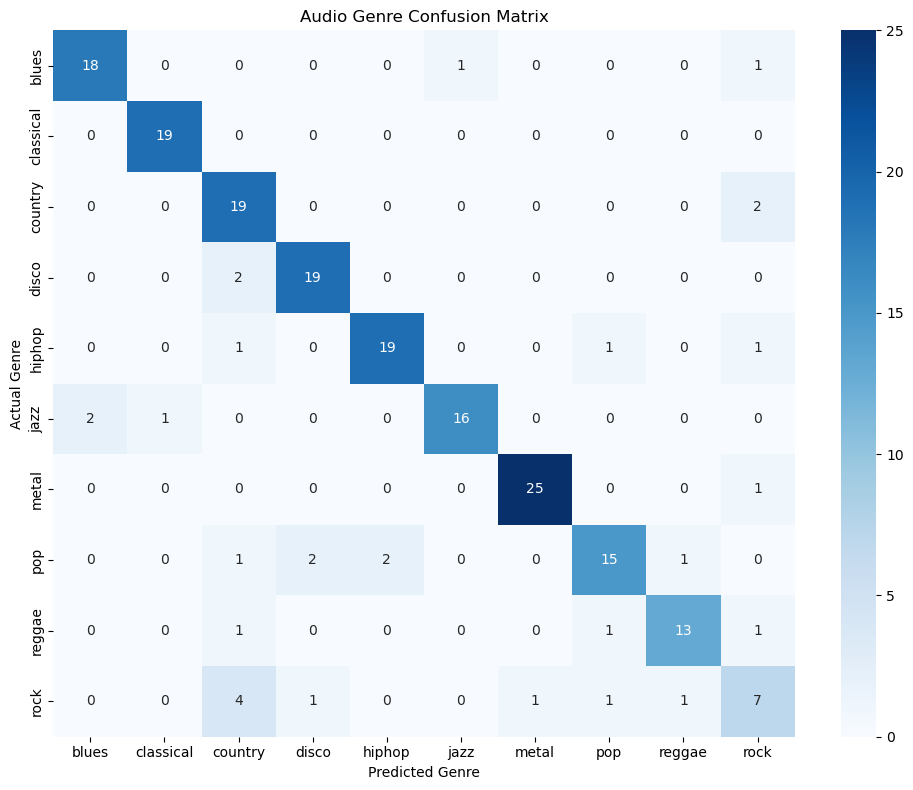

In [23]:
# ==========================================
# 6. Evaluation & Confusion Matrix
# ==========================================
def evaluate_model(model, val_loader, device, classes):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for spectrograms, labels in val_loader:
            spectrograms = spectrograms.to(device)
            labels = labels.to(device)
            
            # Process inputs 
            inputs = process_spectrogram(spectrograms, is_training=False)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Print Classification Report
    print("\n--- Detailed Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes))
    
    # 2. Plot Confusion Matrix Heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    
    plt.ylabel('Actual Genre')
    plt.xlabel('Predicted Genre')
    plt.title('Audio Genre Confusion Matrix')
    plt.tight_layout()
    
    plt.savefig('confusion_matrix.png')
    print("Confusion matrix saved as 'confusion_matrix.png'")
    
    plt.show() 

classes = dataset.genres
evaluate_model(model, val_loader, device, classes)

In [24]:
# Save the model state dictionary to a file
torch.save(model.state_dict(), 'music_genre_cnn.pth')